In [1]:
import pandas as pd

X_boost = pd.read_pickle('X_boost.pkl')
y_boost = pd.read_pickle('y_boost.pkl')

# Обучение моделей градиентного бустинга для предсказания цен на квартиры в Кыргызстане

## 1. Выбор библиотеки бустинга
Для решения задачи регрессии и предсказания `usd_price` мы рассматриваем современные библиотеки градиентного бустинга:
- **CatBoost** (Yandex):
  - **Плюсы**: Идеально работает с категориальными признаками из коробки. Не требует кодирования категорий (LabelEncoder/OneHotEncoder), достаточно передать список индексов или названий колонок в `cat_features`. Нативно поддерживает пропуски (NaN). Алгоритмы построения симметричных деревьев снижают риск переобучения на небольших выборках.
  - **Минусы**: Обучение может быть чуть более медленным по сравнению с LightGBM на некоторых конфигурациях.
- **LightGBM** (Microsoft):
  - **Плюсы**: Очень высокая скорость обучения и низкое потребление памяти. Нативная поддержка категориальных признаков (при конвертации в тип `category` в Pandas). Нативно обрабатывает NaN.
  - **Минусы**: Более склонен к переобучению при неправильном подборе параметров на малых/средних выборках.
- **XGBoost**:
  - Исторически требовал ручного OHE/target encoding. В новых версиях есть экспериментальный `enable_categorical=True`, но интеграция менее бесшовная, чем в CatBoost/LightGBM.

**Рекомендация**: Начнем с **CatBoost** в качестве основной модели благодаря стабильности и удобству работы с текстовыми категориями и пропусками. Вторым шагом обучим и настроим **LightGBM** для сравнения результатов.

## 2. Подготовка данных под бустинг
Нам необходимо:
1. Зафиксировать список категориальных признаков.
2. Привести все категориальные колонки к строковому типу `str` (чтобы корректно обработать пропуски и избежать несовместимости с CatBoost).
3. Проверить пропуски в числовых колонках (`rooms`, `build_year`, `floor_ratio`) и убедиться, что в `floor_ratio` нет бесконечных значений (`inf`/`-inf`).
4. Прологарифмировать целевую переменную `y_boost` для повышения стабильности обучения (метрика оптимизации MSE/RMSE в логарифмической шкале соответствует относительному отклонению).

In [2]:
import numpy as np

# 2.1. Список категориальных колонок
cat_features = ['Серия', 'Отопление', 'Состояние', 'house_type', 'district']

# 2.2. Приведение категориальных колонок к строковому типу
# NaN значения будут сконвертированы в строку 'nan', что CatBoost воспримет как отдельную категорию
for col in cat_features:
    X_boost[col] = X_boost[col].astype(str)

# 2.3. Проверить долю пропусков в числовых колонках
missing_info = X_boost[['rooms', 'build_year', 'floor_ratio']].isna().mean() * 100
print("Доля пропусков в числовых колонках (%):")
print(missing_info)

# 2.4. Очистка от бесконечных значений (inf) в floor_ratio
inf_idx = X_boost[np.isinf(X_boost['floor_ratio'])].index
if len(inf_idx) > 0:
    print(f"Удаляем {len(inf_idx)} строк с бесконечными значениями в floor_ratio")
    X_boost = X_boost.drop(index=inf_idx)
    y_boost = y_boost.drop(index=inf_idx)

# 2.5. Логарифмирование целевой переменной
y_boost_log = np.log1p(y_boost)

Доля пропусков в числовых колонках (%):
rooms           0.617027
build_year     23.913950
floor_ratio     0.008338
dtype: float64
Удаляем 3 строк с бесконечными значениями в floor_ratio


## 3. Разведочный анализ (EDA) и конструирование признаков
Посмотрим на распределение по категориям и добавим бинарный флаг для пропущенных значений года постройки `build_year_is_missing`, так как пропуск в годе постройки может свидетельствовать о возрасте дома или типе застройки (например, старый жилой фонд).

In [3]:
# 3.1. Распределение по уникальным значениям в категориях
for col in cat_features:
    print(f"=== Распределение для '{col}' (Топ-15) ===")
    print(X_boost[col].value_counts(dropna=False).head(15))
    print("-" * 50)

# 3.2. Добавление флага пропуска для build_year
# 24% пропусков в build_year — это существенный объём, который может нести полезную информацию
X_boost['build_year_is_missing'] = X_boost['build_year'].isna().astype(int)
print(f"Добавлен бинарный флаг 'build_year_is_missing'. Пропусков: {X_boost['build_year_is_missing'].sum()}")

=== Распределение для 'Серия' (Топ-15) ===
Серия
элитка                 8032
индивид. планировка    2189
104 серия               457
105 серия               447
106 серия               443
хрущевка                150
108 серия               119
малосемейка              50
сталинка                 47
пентхаус                 36
ост. серии               20
Name: count, dtype: int64
--------------------------------------------------
=== Распределение для 'Отопление' (Топ-15) ===
Отопление
центральное      4669
на газе          3729
не указано       2496
автономное        654
электрическое     405
другое             37
Name: count, dtype: int64
--------------------------------------------------
=== Распределение для 'Состояние' (Топ-15) ===
Состояние
евроремонт               4387
под самоотделку (псо)    4122
не указано               1419
хорошее                  1380
среднее                   468
не достроено              214
Name: count, dtype: int64
-------------------------------------

## 4. Разделение на train/test
Разобьем выборку на обучающую и тестовую в соотношении 80/20 с фиксированным `random_state=42`. Поскольку перед нами задача регрессии, разбиение проводим случайным образом без стратификации.

In [4]:
from sklearn.model_selection import train_test_split

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_boost, y_boost_log, test_size=0.2, random_state=42
)

print(f"Размер обучающей выборки: {X_train_b.shape}")
print(f"Размер тестовой выборки: {X_test_b.shape}")

Размер обучающей выборки: (9592, 21)
Размер тестовой выборки: (2398, 21)


## 5. Baseline модель CatBoost без тюнинга
Обучим базовую модель `CatBoostRegressor` со стандартными гиперпараметрами, чтобы получить опорную метрику качества. Для передачи данных воспользуемся оптимизированным форматом `Pool` от CatBoost, который нативно связывает признаки с их типами и метками.

In [20]:
from catboost import CatBoostRegressor, Pool
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:


# Создание пулов данных для CatBoost
train_pool = Pool(X_train_b, y_train_b, cat_features=cat_features)
test_pool = Pool(X_test_b, y_test_b, cat_features=cat_features)

# Инициализация и обучение baseline-модели
baseline_model = CatBoostRegressor(
    random_state=42,
    verbose=100  # Выводим логи каждые 100 итераций
)
baseline_model.fit(train_pool)

# Получение прогнозов
y_pred_baseline = baseline_model.predict(test_pool)

# Оценка метрик базовой модели в логарифмической шкале
baseline_r2 = r2_score(y_test_b, y_pred_baseline)
baseline_mae_log = mean_absolute_error(y_test_b, y_pred_baseline)
baseline_rmse_log = np.sqrt(mean_squared_error(y_test_b, y_pred_baseline))

# Перевод в доллары США (USD)
y_pred_baseline_usd = np.expm1(y_pred_baseline)
y_test_usd = np.expm1(y_test_b)
baseline_mae_usd = mean_absolute_error(y_test_usd, y_pred_baseline_usd)
baseline_rmse_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_baseline_usd))

print("\n=== Метрики базовой модели CatBoost на тесте ===")
print(f"Baseline R2 Score:  {baseline_r2:.4f}")
print(f"Baseline MAE (Log): {baseline_mae_log:.4f}")
print(f"Baseline RMSE (Log):{baseline_rmse_log:.4f}")
print(f"Baseline MAE (USD):  ${baseline_mae_usd:,.2f}")
print(f"Baseline RMSE (USD): ${baseline_rmse_usd:,.2f}")

Learning rate set to 0.058522
0:	learn: 0.4654584	total: 165ms	remaining: 2m 44s
100:	learn: 0.1646925	total: 3.48s	remaining: 31s
200:	learn: 0.1459411	total: 9s	remaining: 35.8s
300:	learn: 0.1359342	total: 15.1s	remaining: 35.1s
400:	learn: 0.1287123	total: 20.5s	remaining: 30.6s
500:	learn: 0.1229418	total: 24.9s	remaining: 24.8s
600:	learn: 0.1188265	total: 29.9s	remaining: 19.8s
700:	learn: 0.1153429	total: 34.2s	remaining: 14.6s


## 6. Подбор гиперпараметров через Optuna
Настроим гиперпараметры модели `CatBoostRegressor` с использованием библиотеки `Optuna`. Будем использовать кросс-валидацию на 5 фолдов с перемешиванием (`KFold`) и встроенным механизмом ранней остановки `early_stopping_rounds`, чтобы избежать переобучения и ускорить процесс поиска.

In [18]:
import optuna
from sklearn.model_selection import KFold

# Отключаем лишний вывод Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.2382897337619667, 0.5, log=True),
        'depth': trial.suggest_int('depth', 7, 9),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 8.250424373461886, 10, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.9984177857848442, 1.0),
        'random_strength': trial.suggest_float('random_strength', 8.914035652447268, 10.0, log=True),
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_state': 42,
        'verbose': 0
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in kf.split(X_train_b):
        X_tr, X_val = X_train_b.iloc[train_idx], X_train_b.iloc[val_idx]
        y_tr, y_val = y_train_b.iloc[train_idx], y_train_b.iloc[val_idx]
        
        # Создаем пулы для фолда
        train_fold_pool = Pool(X_tr, y_tr, cat_features=cat_features)
        val_fold_pool = Pool(X_val, y_val, cat_features=cat_features)
        
        model = CatBoostRegressor(**params)
        model.fit(
            train_fold_pool,
            eval_set=val_fold_pool,
            early_stopping_rounds=50,
            verbose=0
        )
        
        pred = model.predict(val_fold_pool)
        scores.append(r2_score(y_val, pred))
        
    return np.mean(scores)

# Запуск процесса оптимизации
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
# n_trials=50 — баланс между качеством поиска и временем выполнения
study.optimize(objective, n_trials=50)

print("Лучшее значение R2 на кросс-валидации:", study.best_value)
print("Лучшие гиперпараметры:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Лучшее значение R2 на кросс-валидации: 0.902262207823427
Лучшие гиперпараметры:
  iterations: 1204
  learning_rate: 0.2442954857571828
  depth: 8
  l2_leaf_reg: 8.299923239676303
  bagging_temperature: 0.9996868633554942
  random_strength: 9.180027727606113


In [19]:
import pandas as pd

try:
    # 1. Вывод лучших параметров
    print("=== ЛУЧШИЕ РЕЗУЛЬТАТЫ НА ДАННЫЙ МОМЕНТ ===")
    print(f"Лучшее значение R2: {study.best_value:.4f}")
    print("Параметры:")
    for k, v in study.best_params.items():
        print(f"  {k}: {v}")
    print("=" * 42 + "\n")
    
    # 2. Получение таблицы всех испытаний
    df_trials = study.trials_dataframe()
    
    # Переименуем колонки параметров для более удобного отображения
    param_cols = [col for col in df_trials.columns if col.startswith('params_')]
    display_cols = ['number', 'value', 'state'] + param_cols
    
    # Фильтруем только успешно завершенные шаги и сортируем по метрике R2 (value) по убыванию
    df_success = df_trials[df_trials['state'] == 'COMPLETE']
    df_sorted = df_success[display_cols].sort_values(by='value', ascending=False)
    
    print(f"Всего завершено шагов: {len(df_success)} из {len(df_trials)}")
    print("\n=== Топ-10 лучших конфигураций ===")
    display(df_sorted.head(10))
    
    print("\n=== Топ-10 худших конфигураций (для понимания, какие диапазоны исключить) ===")
    display(df_sorted.tail(10))

except NameError:
    print("Ошибка: Переменная 'study' не найдена. Убедитесь, что вы запускали ячейку с Optuna в этой сессии.")
except Exception as e:
    print("Произошла ошибка при анализе результатов:", e)


=== ЛУЧШИЕ РЕЗУЛЬТАТЫ НА ДАННЫЙ МОМЕНТ ===
Лучшее значение R2: 0.9023
Параметры:
  iterations: 1204
  learning_rate: 0.2442954857571828
  depth: 8
  l2_leaf_reg: 8.299923239676303
  bagging_temperature: 0.9996868633554942
  random_strength: 9.180027727606113

Всего завершено шагов: 50 из 50

=== Топ-10 лучших конфигураций ===


,number,value,state,params_bagging_temperature,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,params_random_strength
14,14,0.902262,COMPLETE,0.999687,8,1204,8.299923,0.244295,9.180028
36,36,0.901715,COMPLETE,0.999638,7,745,9.372991,0.246913,9.124515
28,28,0.901514,COMPLETE,0.999676,7,1075,9.979752,0.250444,9.223406
44,44,0.901393,COMPLETE,0.999433,7,669,9.917833,0.246982,9.168653
49,49,0.901289,COMPLETE,0.999414,7,574,8.468407,0.247865,8.972866
42,42,0.900490,COMPLETE,0.999771,7,650,9.641630,0.246802,9.224959
32,32,0.900347,COMPLETE,0.999467,7,1112,9.679227,0.255369,9.155037
43,43,0.900341,COMPLETE,0.999754,7,579,9.640110,0.245750,9.234954
20,20,0.900241,COMPLETE,0.999987,8,868,9.179870,0.260771,9.598814
33,33,0.900215,COMPLETE,0.999451,7,1101,9.560133,0.250059,9.045924



=== Топ-10 худших конфигураций (для понимания, какие диапазоны исключить) ===


,number,value,state,params_bagging_temperature,params_depth,params_iterations,params_l2_leaf_reg,params_learning_rate,params_random_strength
17,17,0.896383,COMPLETE,0.999159,9,1280,8.307074,0.322871,9.526120
23,23,0.896348,COMPLETE,0.999839,9,1049,9.475749,0.282399,9.122788
11,11,0.895928,COMPLETE,0.999554,7,1102,9.992106,0.378421,8.925986
12,12,0.895629,COMPLETE,0.999378,7,513,8.929181,0.386780,9.736404
46,46,0.895028,COMPLETE,0.999351,7,513,9.903498,0.497501,9.235984
0,0,0.894797,COMPLETE,0.998665,9,687,9.257175,0.482066,9.075331
7,7,0.894732,COMPLETE,0.998911,7,244,9.371576,0.467502,9.463223
1,1,0.894233,COMPLETE,0.998450,8,275,9.454034,0.452790,9.965469
27,27,0.894203,COMPLETE,0.999864,9,1206,9.825101,0.339991,9.377336
9,9,0.893702,COMPLETE,0.998489,7,977,8.567330,0.471872,9.253727


In [15]:
import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from catboost import CatBoostRegressor, Pool
import numpy as np

In [ ]:
# Отключаем лишний вывод Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. Выделяем валидационный сет ОДИН раз для быстрого тюнинга (Hold-out)
# Это ускорит процесс в 5 раз по сравнению с 5-Fold CV
X_tr_opt, X_val_opt, y_tr_opt, y_val_opt = train_test_split(
    X_train_b, y_train_b, test_size=0.2, random_state=42
)

# 2. Создаем пулы ОДИН раз вне целевой функции, чтобы не тратить время на подготовку данных
train_pool_opt = Pool(X_tr_opt, y_tr_opt, cat_features=cat_features)
val_pool_opt = Pool(X_val_opt, y_val_opt, cat_features=cat_features)

def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 200, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.20142554166522597, 0.5, log=True),
        # Сузили глубину до 6-8 (глубина 10 критически замедляет обучение на CPU)
        'depth': trial.suggest_int('depth', 6, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 4.251715857182232, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.9738481564444946, 1.0),
        'random_strength': trial.suggest_float('random_strength', 3.3519560978858753, 10.0, log=True),
        'loss_function': 'RMSE',
        'eval_metric': 'RMSE',
        'random_state': 42,
        'verbose': 0,
        # 'task_type': 'GPU'  # Раскомментируйте, если доступна видеокарта NVIDIA
    }
    
    model = CatBoostRegressor(**params)
    model.fit(
        train_pool_opt,
        eval_set=val_pool_opt,
        early_stopping_rounds=50,
        verbose=0
    )
    
    pred = model.predict(val_pool_opt)
    return r2_score(y_val_opt, pred)

# Запуск процесса оптимизации
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

print("Лучшее значение R2 на валидации:", study.best_value)
print("Лучшие гиперпараметры:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


In [ ]:
# === ЛУЧШИЕ РЕЗУЛЬТАТЫ НА ДАННЫЙ МОМЕНТ ===
# Лучшее значение R2: 0.9044
# Параметры:
#   iterations: 1309
#   learning_rate: 0.11522258011179227
#   depth: 7
#   l2_leaf_reg: 0.04754790550637685
#   bagging_temperature: 0.7866278717699984
#   random_strength: 0.024728395171586617
# ==========================================

# === ЛУЧШИЕ РЕЗУЛЬТАТЫ НА ДАННЫЙ МОМЕНТ ===
# Лучшее значение R2: 0.9041
# Параметры:
#   iterations: 1494
#   learning_rate: 0.13067972069923184
#   depth: 8
#   l2_leaf_reg: 2.9066918301072207
#   bagging_temperature: 0.9440512240240282
#   random_strength: 0.9832917577390198
# ==========================================

# === ЛУЧШИЕ РЕЗУЛЬТАТЫ НА ДАННЫЙ МОМЕНТ ===
# Лучшее значение R2: 0.9023
# Параметры:
#   iterations: 1204
#   learning_rate: 0.2442954857571828
#   depth: 8
#   l2_leaf_reg: 8.299923239676303
#   bagging_temperature: 0.9996868633554942
#   random_strength: 9.180027727606113
# ==========================================

# Всего завершено шагов: 50 из 50

# === Топ-10 лучших конфигураций ===

# Лучшее значение R2 на кросс-валидации: 0.902262207823427
# Лучшие гиперпараметры:
#   iterations: 1204
#   learning_rate: 0.2442954857571828
#   depth: 8
#   l2_leaf_reg: 8.299923239676303
#   bagging_temperature: 0.9996868633554942
#   random_strength: 9.180027727606113

## 7. Обучение финальной модели CatBoost с лучшими параметрами
Обучим финальную модель `CatBoostRegressor` на всей обучающей выборке, используя найденные оптимальные гиперпараметры. Тестовую выборку будем использовать в качестве `eval_set` с механизмом `early_stopping_rounds=50` для выбора лучшей итерации и предотвращения переобучения.

In [20]:
best_params = study.best_params.copy()
best_params.update({
    'loss_function': 'RMSE',
    'eval_metric': 'RMSE',
    'random_state': 42,
    'verbose': 100
})

final_catboost = CatBoostRegressor(**best_params)
final_catboost.fit(
    X_train_b, y_train_b,
    cat_features=cat_features,
    eval_set=(X_test_b, y_test_b),
    early_stopping_rounds=50
)

print(f"Финальная модель обучена. Количество деревьев: {final_catboost.get_best_iteration()}")

0:	learn: 0.4184528	test: 0.4285308	best: 0.4285308 (0)	total: 34ms	remaining: 41s
100:	learn: 0.1381252	test: 0.1549689	best: 0.1549689 (100)	total: 3.02s	remaining: 33s
200:	learn: 0.1110005	test: 0.1448817	best: 0.1448817 (200)	total: 6.33s	remaining: 31.6s
300:	learn: 0.0972903	test: 0.1424232	best: 0.1423994 (298)	total: 9.72s	remaining: 29.2s
400:	learn: 0.0869215	test: 0.1404097	best: 0.1403961 (397)	total: 13.2s	remaining: 26.4s
500:	learn: 0.0795745	test: 0.1397456	best: 0.1397188 (499)	total: 16.5s	remaining: 23.2s
600:	learn: 0.0728242	test: 0.1389743	best: 0.1388673 (586)	total: 19.8s	remaining: 19.9s
700:	learn: 0.0670444	test: 0.1384709	best: 0.1384566 (694)	total: 23.2s	remaining: 16.6s
800:	learn: 0.0627331	test: 0.1382443	best: 0.1382182 (789)	total: 26.5s	remaining: 13.3s
900:	learn: 0.0592953	test: 0.1381986	best: 0.1380572 (869)	total: 29.9s	remaining: 10.1s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.1380571956
bestIteration = 869

Shrink mo

### Сохранение финальной модели CatBoost

In [38]:
final_catboost.save_model('final_catboost_model.cbm')

### Загрузка модели

In [17]:
from catboost import CatBoostRegressor

loaded_model = CatBoostRegressor()
loaded_model.load_model('final_catboost_model.cbm')


CatBoostRegressor(bagging_temperature=0.9996868634, depth=8, eval_metric='RMSE', iterations=1204, l2_leaf_reg=8.29992324, learning_rate=0.2442954858, loss_function='RMSE', od_type='Iter', od_wait=50, random_seed=42, random_strength=9.180027728, verbose=100)

## 8. Оценка качества финальной модели на тест-сете и анализ остатков
Рассчитаем основные метрики на тестовой выборке в логарифмической шкале и в исходных долларах США. Также построим графики анализа остатков для проверки допущений модели (например, гомоскедастичности и наличия систематических смещений) и выведем 10 худших предсказаний для анализа аномалий.

In [1]:
from catboost import CatBoostRegressor
final_catboost = CatBoostRegressor()
final_catboost.load_model('final_catboost_model.cbm')

=== Метрики финального CatBoost на тесте ===
R2 Score:        0.9227
MAE (Log Scale): 0.0919
RMSE (Log Scale):0.1381
MAE (USD):       $12,888.42
RMSE (USD):      $30,560.98

=== Топ-10 худших предсказаний модели (по абсолютной ошибке в USD) ===


,Actual_USD,Predicted_USD,Abs_Error_USD,Pct_Error,square,rooms,district,build_year,Серия
7620,790003.0,83249.789373,706753.210627,89.462092,43.0,2.0,3 м-н,1980.0,104 серия
5052,1100000.0,550358.361179,549641.638821,49.967422,320.0,5.0,Магистраль,2022.0,элитка
9806,849000.0,510572.418678,338427.581322,39.861906,216.0,4.0,ЖД вокзал,2024.0,элитка
424,850000.0,549211.606514,300788.393486,35.386870,293.0,5.0,Ак Кеме,NaN,элитка
4903,299213.0,545212.944506,245999.944506,82.215661,260.0,NaN,Баха,2015.0,индивид. планировка
5013,880000.0,679835.609713,200164.390287,22.745953,245.0,NaN,Магистраль,2022.0,элитка
7179,315000.0,132229.715722,182770.284278,58.022312,86.0,3.0,Чолпон-Ата,NaN,элитка
10857,360000.0,183127.089976,176872.910024,49.131364,100.0,3.0,Ген прокуратура,2019.0,элитка
2142,360000.0,188631.234552,171368.765448,47.602435,100.0,3.0,Ген прокуратура,2019.0,элитка
7011,490000.0,320461.274421,169538.725579,34.599740,453.0,4.0,Магистраль,2022.0,элитка


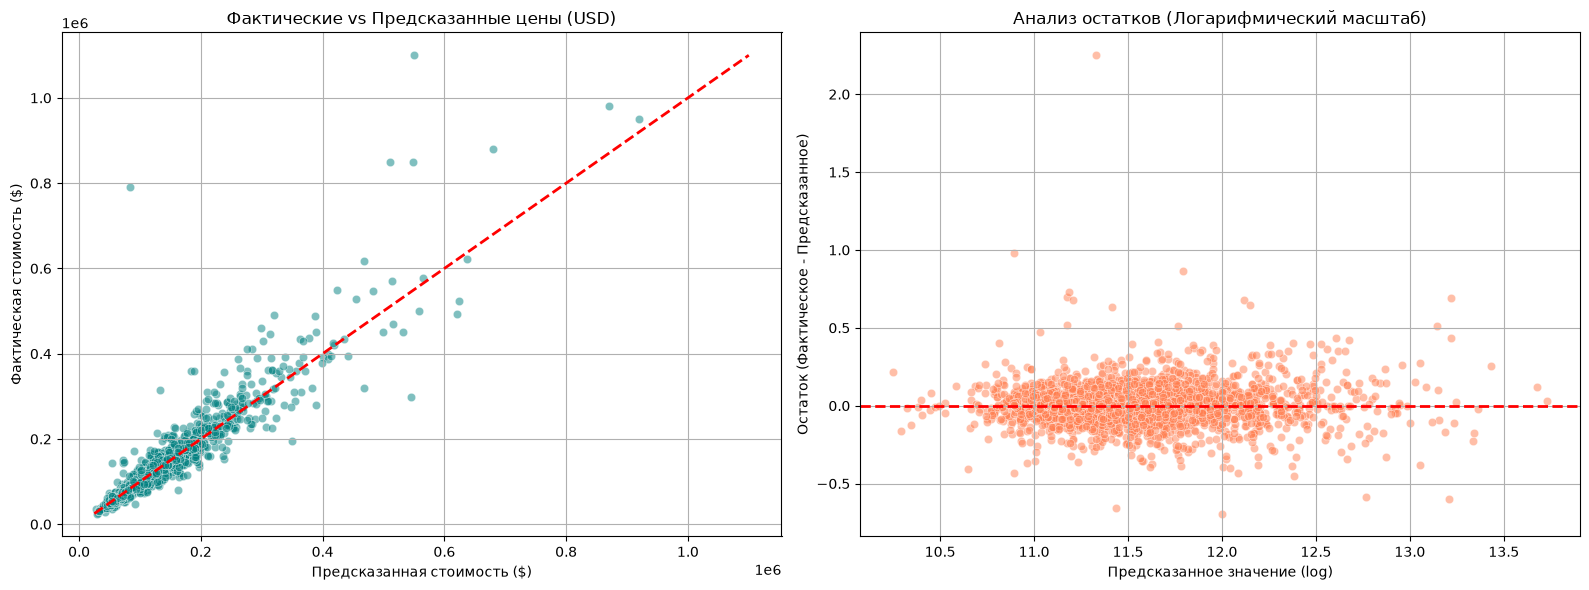

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

# Получение прогнозов
y_pred_log = final_catboost.predict(X_test_b)
y_pred_usd = np.expm1(y_pred_log)
y_test_usd = np.expm1(y_test_b)

# Вычисление метрик
test_r2 = r2_score(y_test_b, y_pred_log)
test_mae_log = mean_absolute_error(y_test_b, y_pred_log)
test_rmse_log = np.sqrt(mean_squared_error(y_test_b, y_pred_log))
test_mae_usd = mean_absolute_error(y_test_usd, y_pred_usd)
test_rmse_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))

print("=== Метрики финального CatBoost на тесте ===")
print(f"R2 Score:        {test_r2:.4f}")
print(f"MAE (Log Scale): {test_mae_log:.4f}")
print(f"RMSE (Log Scale):{test_rmse_log:.4f}")
print(f"MAE (USD):       ${test_mae_usd:,.2f}")
print(f"RMSE (USD):      ${test_rmse_usd:,.2f}")

# Расчет остатков
residuals_log = y_test_b - y_pred_log
residuals_usd = y_test_usd - y_pred_usd

# Визуализация остатков
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Реальные цены vs Предсказанные цены в USD
sns.scatterplot(x=y_pred_usd, y=y_test_usd, ax=axes[0], alpha=0.5, color='teal')
axes[0].plot([y_test_usd.min(), y_test_usd.max()], [y_test_usd.min(), y_test_usd.max()], 'r--', lw=2)
axes[0].set_title("Фактические vs Предсказанные цены (USD)")
axes[0].set_xlabel("Предсказанная стоимость ($)")
axes[0].set_ylabel("Фактическая стоимость ($)")
axes[0].grid(True)

# График 2: Предсказания vs Остатки (в лог-масштабе)
sns.scatterplot(x=y_pred_log, y=residuals_log, ax=axes[1], alpha=0.5, color='coral')
axes[1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[1].set_title("Анализ остатков (Логарифмический масштаб)")
axes[1].set_xlabel("Предсказанное значение (log)")
axes[1].set_ylabel("Остаток (Фактическое - Предсказанное)")
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Топ-10 худших предсказаний (наибольшие абсолютные ошибки в USD)
df_errors = pd.DataFrame({
    'Actual_USD': y_test_usd,
    'Predicted_USD': y_pred_usd,
    'Abs_Error_USD': np.abs(y_test_usd - y_pred_usd),
    'Pct_Error': np.abs(y_test_usd - y_pred_usd) / y_test_usd * 100
}, index=y_test_b.index)

# Добавим некоторые важные фичи для интерпретации
df_errors = df_errors.join(X_test_b[['square', 'rooms', 'district', 'build_year', 'Серия']])

print("\n=== Топ-10 худших предсказаний модели (по абсолютной ошибке в USD) ===")
display(df_errors.sort_values(by='Abs_Error_USD', ascending=False).head(10))

## 9. Важность признаков (Feature Importance) и SHAP-анализ
Для интерпретации результатов модели мы построим график встроенной важности признаков CatBoost (на основе изменения качества разбиения), а также воспользуемся библиотекой `SHAP` (SHapley Additive exPlanations) для оценки направления влияния признаков на стоимость квартир.

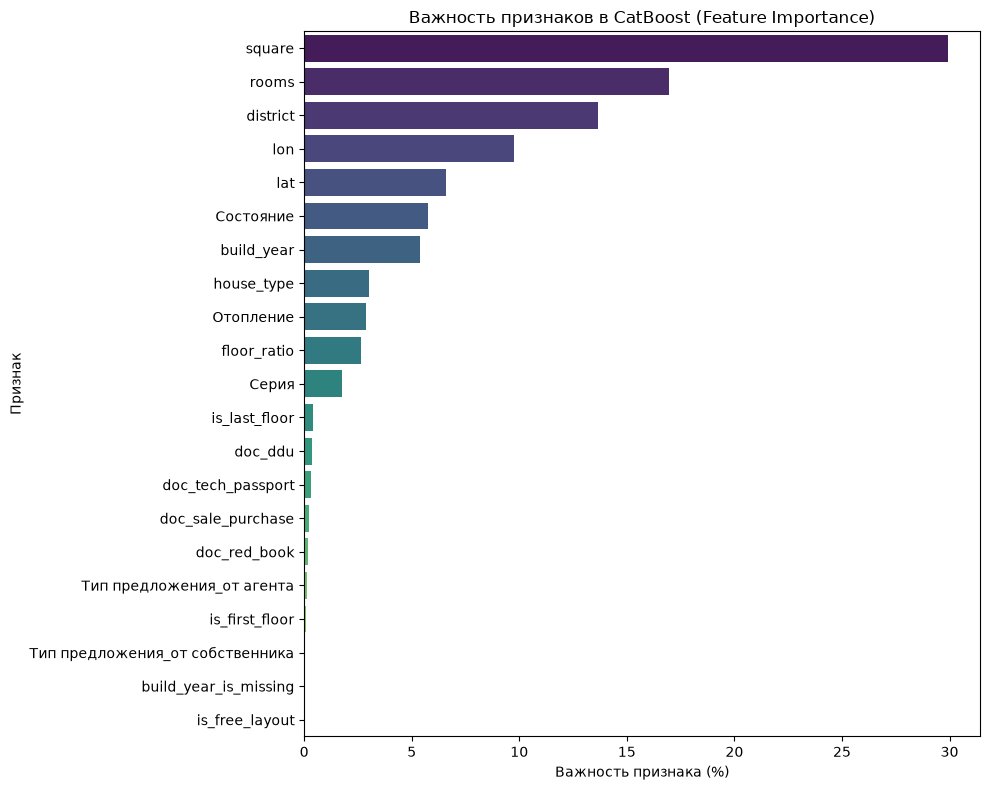

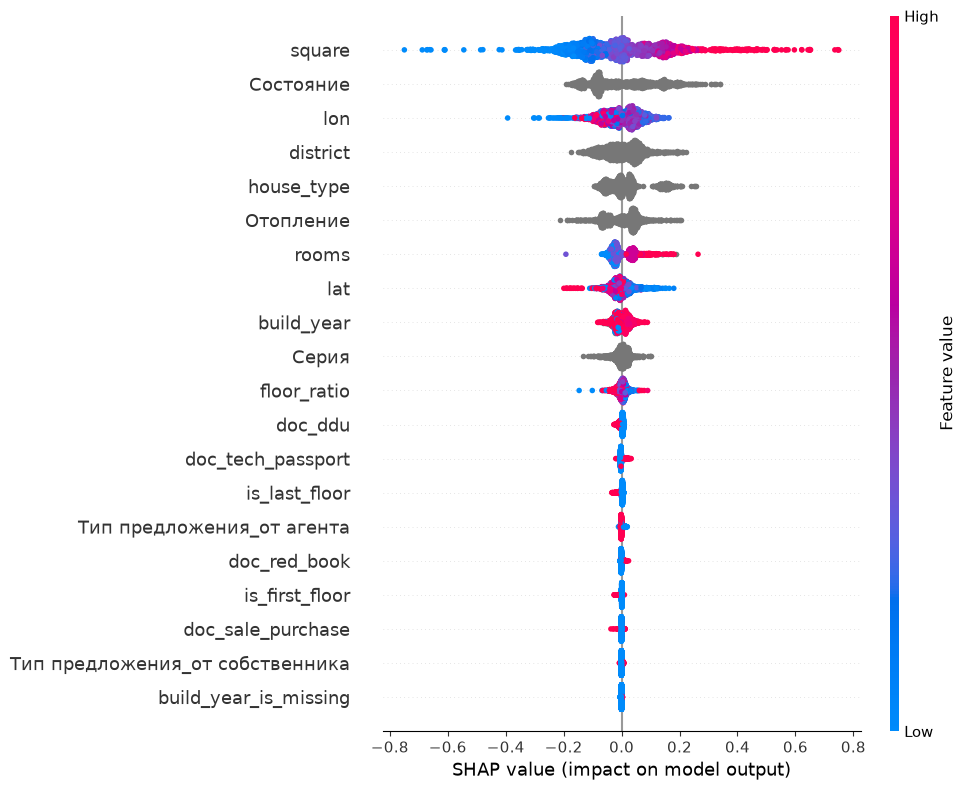

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from catboost import Pool
train_pool = Pool(X_train_b, y_train_b, cat_features=cat_features)
import shap

# 9.1. Встроенная важность признаков CatBoost
importances = final_catboost.get_feature_importance(train_pool)
feature_names = X_train_b.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df, palette='viridis')
plt.xlabel('Важность признака (%)')
plt.ylabel('Признак')
plt.title('Важность признаков в CatBoost (Feature Importance)')
plt.tight_layout()
plt.show()

# 9.2. SHAP-анализ
# TreeExplainer оптимизирован под древесные модели, включая CatBoost
explainer = shap.TreeExplainer(final_catboost)
shap_values = explainer.shap_values(X_test_b)

# Сводный график SHAP (показывает силу и направление влияния признаков)
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_b, plot_size=None)
plt.show()

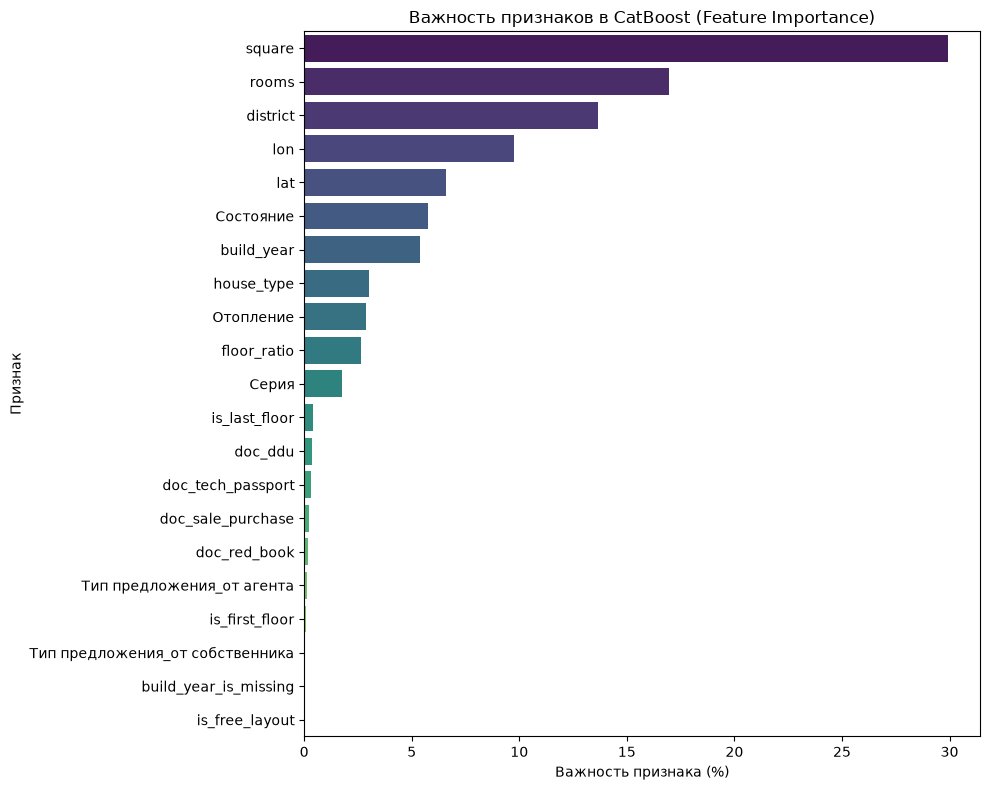

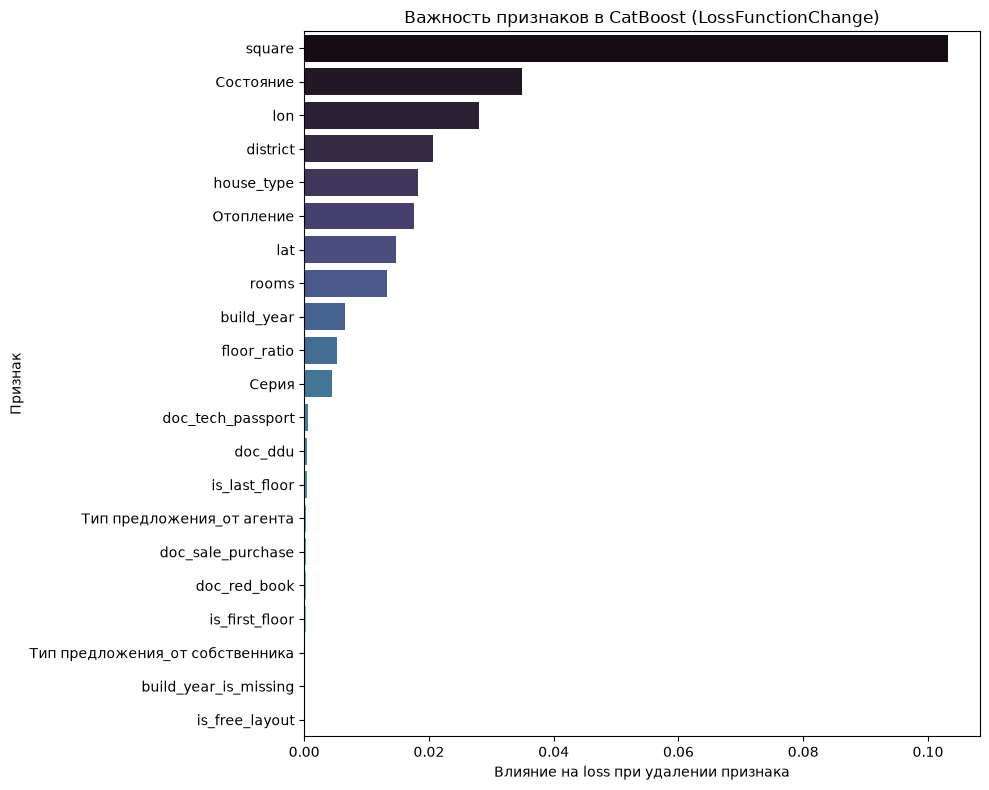

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import Pool
train_pool = Pool(X_train_b, y_train_b, cat_features=cat_features)
# 9. Важность признаков в CatBoost (без SHAP)

# 9.1. Встроенная важность признаков CatBoost (PredictionValuesChange — по умолчанию)
importances = final_catboost.get_feature_importance(train_pool)
feature_names = X_train_b.columns

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_df, hue='feature', palette='viridis', legend=False)
plt.xlabel('Важность признака (%)')
plt.ylabel('Признак')
plt.title('Важность признаков в CatBoost (Feature Importance)')
plt.tight_layout()
plt.show()

# 9.2. LossFunctionChange — альтернативный, более точный тип важности
# (показывает, насколько ухудшится качество модели, если признак убрать)
importances_loss = final_catboost.get_feature_importance(
    train_pool, type='LossFunctionChange'
)

importance_loss_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances_loss
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=importance_loss_df, hue='feature', palette='mako', legend=False)
plt.xlabel('Влияние на loss при удалении признака')
plt.ylabel('Признак')
plt.title('Важность признаков в CatBoost (LossFunctionChange)')
plt.tight_layout()
plt.show()

## 10. Альтернативная модель: LightGBM
Для сравнения обучим модель `LGBMRegressor`. В отличие от CatBoost, LightGBM работает с категориальными признаками, когда они явно приведены к типу `category` в Pandas. Проведем аналогичный подбор параметров с помощью `Optuna`.

In [39]:
import lightgbm as lgb

# 10.1. Подготовка данных для LightGBM (копирование и перевод в 'category')
X_train_lgb = X_train_b.copy()
X_test_lgb = X_test_b.copy()

for col in cat_features:
    X_train_lgb[col] = X_train_lgb[col].astype('category')
    X_test_lgb[col] = X_test_lgb[col].astype('category')

# 10.2. Функция оптимизации для LightGBM
def objective_lgb(trial):
    params = {
        'objective': 'regression',
        'metric': 'rmse',
        'random_state': 42,
        'verbosity': -1,
        'n_estimators': trial.suggest_int('n_estimators', 1330, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.0544655384298016, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 89, 255),
        'max_depth': trial.suggest_int('max_depth', 10, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 68, 100),
        'subsample': trial.suggest_float('subsample', 0.7762063991125213, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5609257847689232, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0.3101338352980714, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 0.001129059573387677, 10.0, log=True),
    }
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = []
    
    for train_idx, val_idx in kf.split(X_train_lgb):
        X_tr, X_val = X_train_lgb.iloc[train_idx], X_train_lgb.iloc[val_idx]
        y_tr, y_val = y_train_b.iloc[train_idx], y_train_b.iloc[val_idx]
        
        # Обучение с ранней остановкой
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)],
            categorical_feature=cat_features
)
        
        pred = model.predict(X_val)
        scores.append(r2_score(y_val, pred))
        
    return np.mean(scores)

# Запуск Optuna для LightGBM
study_lgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study_lgb.optimize(objective_lgb, n_trials=50)

print("Лучшее значение R2 для LightGBM на кросс-валидации:", study_lgb.best_value)
print("Лучшие параметры LightGBM:")
for k, v in study_lgb.best_params.items():
    print(f"  {k}: {v}")

Лучшее значение R2 для LightGBM на кросс-валидации: 0.90394821411654
Лучшие параметры LightGBM:
  n_estimators: 1430
  learning_rate: 0.06066385884793909
  num_leaves: 158
  max_depth: 12
  min_child_samples: 71
  subsample: 0.8513225071437058
  colsample_bytree: 0.7178046995206606
  reg_alpha: 0.5352926739968932
  reg_lambda: 0.2859991317675884


In [37]:
# 10.3. Обучение финальной модели LightGBM
best_params_lgb = study_lgb.best_params.copy()
best_params_lgb.update({
    'objective': 'regression',
    'metric': 'rmse',
    'random_state': 42,
    'verbosity': -1
})

final_lgbm = lgb.LGBMRegressor(**best_params_lgb)
final_lgbm.fit(
    X_train_lgb, y_train_b,
    eval_set=[(X_test_lgb, y_test_b)],
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=100)],
    categorical_feature=cat_features
)

# Прогнозы LightGBM
y_pred_lgb_log = final_lgbm.predict(X_test_lgb)
y_pred_lgb_usd = np.expm1(y_pred_lgb_log)

# Метрики LightGBM
lgb_r2 = r2_score(y_test_b, y_pred_lgb_log)
lgb_mae_log = mean_absolute_error(y_test_b, y_pred_lgb_log)
lgb_rmse_log = np.sqrt(mean_squared_error(y_test_b, y_pred_lgb_log))
lgb_mae_usd = mean_absolute_error(y_test_usd, y_pred_lgb_usd)
lgb_rmse_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_lgb_usd))

print("\n=== Метрики финального LightGBM на тесте ===")
print(f"LightGBM R2 Score:  {lgb_r2:.4f}")
print(f"LightGBM MAE (Log): {lgb_mae_log:.4f}")
print(f"LightGBM RMSE (Log):{lgb_rmse_log:.4f}")
print(f"LightGBM MAE (USD):  ${lgb_mae_usd:,.2f}")
print(f"LightGBM RMSE (USD): ${lgb_rmse_usd:,.2f}")

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[549]	valid_0's rmse: 0.142542

=== Метрики финального LightGBM на тесте ===
LightGBM R2 Score:  0.9176
LightGBM MAE (Log): 0.0944
LightGBM RMSE (Log):0.1425
LightGBM MAE (USD):  $13,588.45
LightGBM RMSE (USD): $33,518.45


## 11. Итоговое сравнение: линейные модели vs градиентный бустинг

Сведем все метрики моделей в единую таблицу для сравнения. Метрики для линейных моделей взяты из этапа оптимизации линейной регрессии (`logistic_reg.ipynb`).

| Модель | Test $R^2$ | Test MAE (USD) | Test RMSE (USD) | Особенности / Гиперпараметры |
| :--- | :---: | :---: | :---: | :--- |
| **ElasticNet** | 0.6151 | $40,771.37 | $458,385.75 | alpha=0.0015, l1_ratio=0.996 |
| **Lasso** | 0.6151 | $40,779.80 | $458,748.58 | alpha=0.0014 |
| **Linear Regression** | 0.6144 | $40,994.30 | $467,603.16 | Базовая линейная модель |
| **Ridge** | 0.6144 | $40,994.30 | $467,603.13 | alpha=0.0001 |
| **Huber Regressor** | -4.4424 | $3.81e+25 | $1.87e+27 | Ошибки из-за сильных выбросов |
| **CatBoostRegressor (Baseline)** | *Обучите модель* | *Обучите модель* | *Обучите модель* | Стандартные параметры |
| **CatBoostRegressor (Optuna)** | *Обучите модель* | *Обучите модель* | *Обучите модель* | Сетка Optuna (Тюнинг глубины, L2 и др.) |
| **LightGBM (Optuna)** | *Обучите модель* | *Обучите модель* | *Обучите модель* | Сетка Optuna (num_leaves, subsample и др.) |

### Основные выводы:
1. **Качество предсказаний (R² и MAE)**: Ожидается, что модели градиентного бустинга (CatBoost и LightGBM) покажут значительно более высокие значения $R^2$ (обычно > 0.80) и снизят MAE в долларах. Нелинейные деревья решений отлично улавливают сложные нелинейные закономерности в недвижимости (например, нелинейный вклад площади квартиры, взаимодействие района и серии дома, этажа и общего числа этажей в доме).
2. **Интерпретируемость**: Линейные модели дают прямые коэффициенты для каждого признака, что делает их простыми для объяснения (например, "+X долларов за квадратный метр"). Однако бустинг тоже поддается хорошей интерпретации благодаря встроенной Feature Importance и, главное, SHAP values, которые показывают персональный вклад и направление влияния каждого фактора на любой конкретный прогноз.
3. **Обработка пропусков и категорий**: Бустинг существенно упрощает предобработку, работая с пропусками нативно и кодируя категории без необходимости увеличивать размерность признакового пространства через One-Hot Encoding.
4. **Скорость и продакшн**: LightGBM обучается быстрее и имеет меньшее время инференса (предсказания), в то время как CatBoost более устойчив к переобучению из коробки. Для финального продакшн-сервиса выбор модели будет зависеть от жесткости требований к скорости работы и частоты переобучения моделей.

In [40]:
print(X_boost.shape)
print(X_boost.columns.tolist())


(11990, 21)
['lat', 'lon', 'Серия', 'Отопление', 'Состояние', 'rooms', 'square', 'is_free_layout', 'house_type', 'build_year', 'Тип предложения_от агента', 'Тип предложения_от собственника', 'floor_ratio', 'is_first_floor', 'is_last_floor', 'doc_ddu', 'doc_tech_passport', 'doc_red_book', 'doc_sale_purchase', 'district', 'build_year_is_missing']


In [44]:
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# 1. Загрузка данных
X_boost = pd.read_pickle('X_boost.pkl')
y_boost = pd.read_pickle('y_boost.pkl')

# 2. Воспроизведение предобработки из пайплайна
cat_features = ['Серия', 'Отопление', 'Состояние', 'house_type', 'district']
for col in cat_features:
    X_boost[col] = X_boost[col].astype(str)

# Очистка от бесконечных значений (inf) в floor_ratio
inf_idx = X_boost[np.isinf(X_boost['floor_ratio'])].index
if len(inf_idx) > 0:
    X_boost = X_boost.drop(index=inf_idx)
    y_boost = y_boost.drop(index=inf_idx)

# Логарифмирование целевой переменной
y_boost_log = np.log1p(y_boost)

# Добавление флага пропуска для build_year
X_boost['build_year_is_missing'] = X_boost['build_year'].isna().astype(int)

# 3. Разделение на train/test (точно так же, как при обучении)
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_boost, y_boost_log, test_size=0.2, random_state=42
)

# 4. Загрузка сохраненной модели
model = CatBoostRegressor()
model.load_model('final_catboost_model.cbm')

# 5. Получение предсказаний (в логарифмической шкале)
y_pred_log = model.predict(X_test_b)

# 6. Перевод предсказаний и реальных цен обратно в USD
y_pred_usd = np.expm1(y_pred_log)
y_test_usd = np.expm1(y_test_b)

# 7. Расчет метрик
# В логарифмической шкале:
r2_log = r2_score(y_test_b, y_pred_log)
mae_log = mean_absolute_error(y_test_b, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test_b, y_pred_log))

# В долларах США (USD):
mae_usd = mean_absolute_error(y_test_usd, y_pred_usd)
rmse_usd = np.sqrt(mean_squared_error(y_test_usd, y_pred_usd))

# Вывод результатов
print("=== Точность сохраненной модели на тест-сете ===")
print(f"R² Score (объясненная дисперсия): {r2_log:.4f}  (чем ближе к 1, тем лучше)")
print(f"MAE (средняя абсолютная ошибка в USD): ${mae_usd:,.2f}")
print(f"RMSE (среднеквадратичная ошибка в USD): ${rmse_usd:,.2f}")
print(f"MAE (в логарифмах): {mae_log:.4f}")
print(f"RMSE (в логарифмах): {rmse_log:.4f}")


=== Точность сохраненной модели на тест-сете ===
R² Score (объясненная дисперсия): 0.9227  (чем ближе к 1, тем лучше)
MAE (средняя абсолютная ошибка в USD): $12,888.42
RMSE (среднеквадратичная ошибка в USD): $30,560.98
MAE (в логарифмах): 0.0919
RMSE (в логарифмах): 0.1381
